# Ejercicio de feedback 1: Explicabilidad de Modelos de Clasificacion con SHAP

In [1]:
# Instalación
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install shap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

/home/vali0n/Documentos/master_ai/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


En esta sección se ha cargado el dataset y se ha realizado un análisis exploratorio para entender:
- Estructura y tipos de datos
- Valores anómalos o fuera de rango
- Distribuciones de variables clave

Este análisis es fundamental para detectar problemas de calidad de datos que puedan afectar el rendimiento del modelo.

In [3]:
df = pd.read_excel('credit-card-clients.xls', header=1)
df.sample(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
26311,26312,210000,2,2,2,28,-2,-2,-2,-2,...,1577,0,0,0,0,1577,0,0,0,0
29150,29151,360000,2,2,1,61,2,0,0,0,...,260113,263229,268446,13869,11644,12307,9474,9662,9794,1
16790,16791,250000,1,5,1,39,-2,-2,-2,-2,...,0,0,0,3700,0,0,0,0,0,0
8634,8635,230000,1,2,2,27,-1,-1,-1,-1,...,396,396,546,396,396,396,396,546,396,0
24007,24008,230000,1,2,2,27,0,0,0,0,...,8430,9811,9865,1816,5105,1293,2000,528,3000,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

### Exploración inicial y análisis descriptivo

In [5]:
df[["EDUCATION", "MARRIAGE"]].describe()

,EDUCATION,MARRIAGE
count,30000.000000,30000.000000
mean,1.853133,1.551867
std,0.790349,0.521970
min,0.000000,0.000000
25%,1.000000,1.000000
50%,2.000000,2.000000
75%,2.000000,2.000000
max,6.000000,3.000000


Observando la información anterior es posible identificar incoherencias en la variable "EDUCATION" y en la variable "MARRIAGE", donde existen valores no documentados, como valores 0 y mayores que 4 en el caso de "EDUCATION", y valores 0 en "MARRIAGE", que no forman para de ninguna de las categorías. La imputación de estas variables se ha realizado en función de su valor asignado a la categoría "Otro", donde se asignó 4 en "EDUCATION" y 3 en "MARRIAGE"

In [6]:
# Reemplazo los valores anómalos a la categoría "Otro" sustituyendo el Series
df["EDUCATION"] = df["EDUCATION"].replace([0, 5, 6], 4)
df["MARRIAGE"] = df["MARRIAGE"].replace(0, 3)

In [7]:
# Hago un rename de la variable default payment next month
df = df.rename(columns = {"default payment next month": "default"})

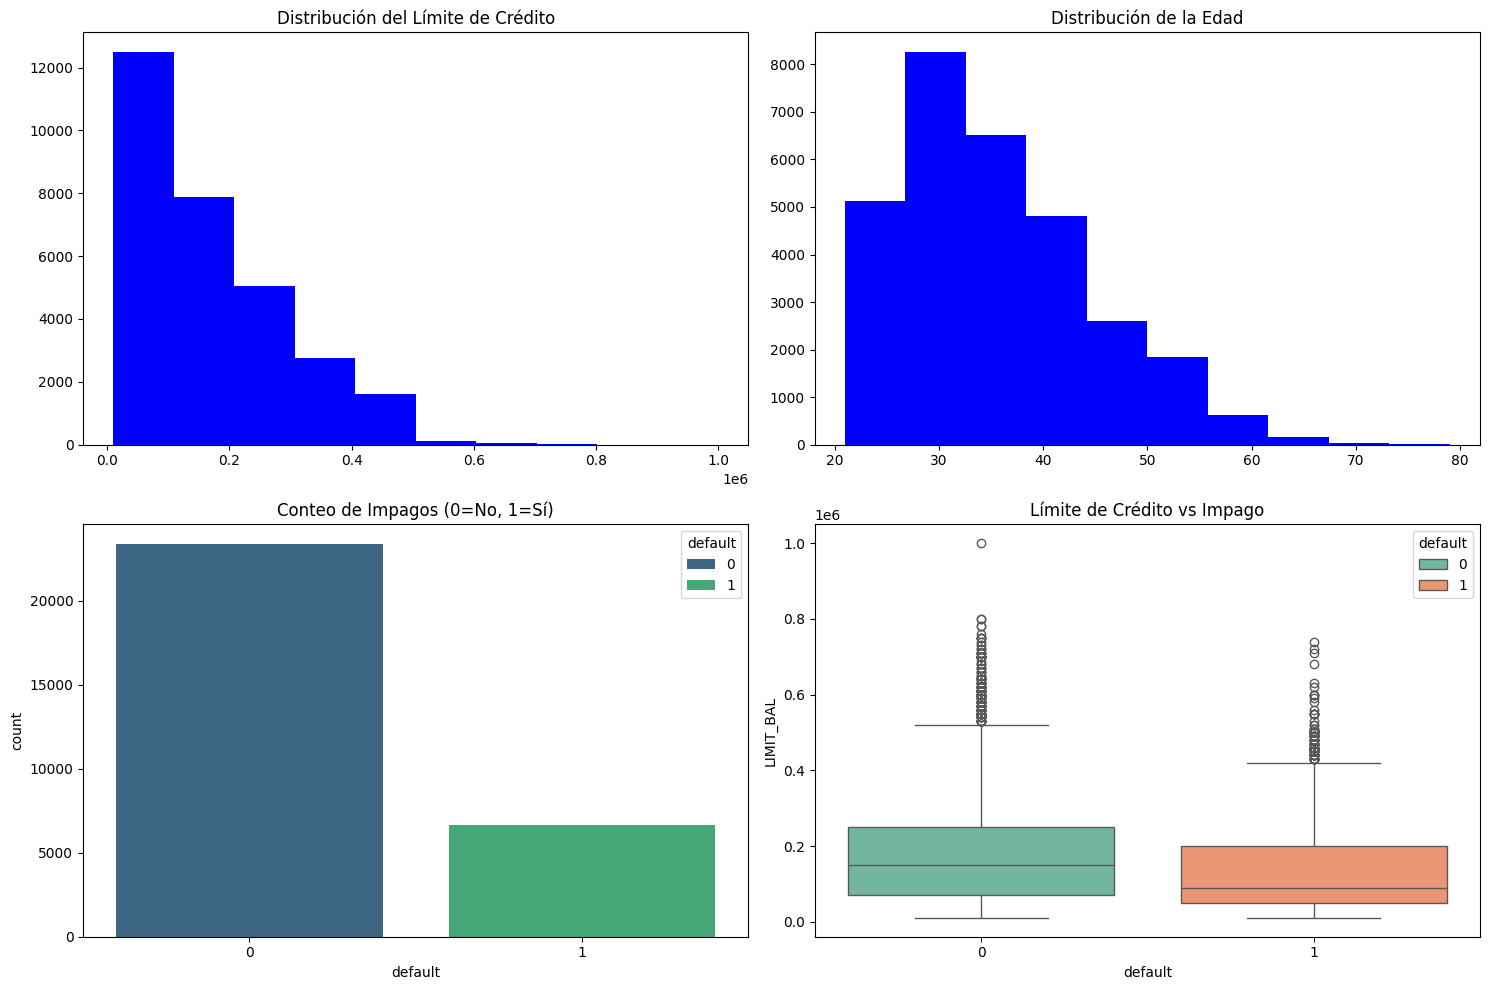

In [8]:
fig = plt.figure(figsize=(15,10))

plt.subplot(2, 2, 1)
plt.hist(df["LIMIT_BAL"], color="blue")
plt.title('Distribución del Límite de Crédito')

plt.subplot(2, 2, 2)
plt.hist(df["AGE"], color="blue")
plt.title('Distribución de la Edad')

plt.subplot(2, 2, 3)
sns.countplot(x = "default", data=df, palette='viridis', hue="default")
plt.title('Conteo de Impagos (0=No, 1=Sí)')

plt.subplot(2, 2, 4)
sns.boxplot(x="default", y="LIMIT_BAL", data=df, palette='Set2', hue="default")
plt.title('Límite de Crédito vs Impago')

plt.tight_layout()
plt.show()

### Entrenamiento y evaluación de modelos

In [10]:
# Separo las variables independientes de la variable dependiente
X = df.drop('default', axis=1)
y = df['default']

# Divido el conjunto de datos en train (80%) y test (20%) y estratifico la variable objetivo
# para contar con un numero similar de observaciones tanto en training como en test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Defino en un diccionario todos los modelos para ser entrenados y evaluados de forma conjunta
# En el caso de la regresión logística los datos fueron normalizados por su importancia a la hora de entrenar el modelo
modelos = {
    'Random Forest': RandomForestClassifier(
                        n_estimators=150,
                        max_depth=8,
                        min_samples_leaf=4,
                        random_state=42,
                        n_jobs=-1,
                        class_weight='balanced'
                    ),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(
                                                                class_weight='balanced',
                                                                max_iter=2000,
                                                                random_state=42
                                                            )
                    ),
    'Gradient Boosting': GradientBoostingClassifier(
                        n_estimators=100,
                        learning_rate=0.1,
                        max_depth=3,
                        random_state=42
                    )
}

In [18]:
# Lista donde se almacenaran los resultados
results = []

for name, model in modelos.items():
    
    model.fit(X_train, y_train)

    # Obtengo las predicciones para el conjunto de test (pago o impago) y probabilidades para AUC
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    # Evalúo cada modelo sobre el conjunto de test usando classification_report
    print(f"Classification report para el modelo {name}")
    print(classification_report(y_test, y_pred))

    # Cálculo del roc_auc_score
    auc = roc_auc_score(y_test, y_proba)
    # Saco la salida del classification report a diccionario para extraer el F1-score
    reporte_dict = classification_report(y_test, y_pred, output_dict=True)
    f1_clase_1 = reporte_dict['1']['f1-score']
    
    print(f"ROC AUC Score: {auc}")

    # Añado un diccionario para cada modelo en la lista de resultados
    results.append(
        {
            'Modelo': name,
            'AUC': auc,
            'F1-Score': f1_clase_1
        }
    )


Classification report para el modelo Random Forest
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.51      0.59      0.55      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.80      0.78      0.79      6000

ROC AUC Score: 0.7739033305698322
Classification report para el modelo Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.71      6000

ROC AUC Score: 0.7087922392760863
Classification report para el modelo Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
      

In [19]:
df_resultados = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
display(df_resultados)

,Modelo,AUC,F1-Score
2,Gradient Boosting,0.779253,0.472940
0,Random Forest,0.773903,0.545582
1,Logistic Regression,0.708792,0.464306


### Explicabilidad del modelo con SHAP

In [ ]:
# Le indico a SHAP que me explique cómo piensa el modelo ganador Random Forest
explainer=shap.TreeExplainer(modelos['Random Forest'])
# SHAP coge a todos los clientes del conjunto de test (X_test) y calcula el valor SHAP, que indica
# cuánto ha empujado esa variable la decisión final del modelo
shap_values=explainer.shap_values(X_test)
# Extraigo la capa que me interesa, que es el impago, de forma que lo que se graficará explicará el
# riesgo de impago, y no el de pago
shap_values_positive = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values
# Extrae el base value, que es la probabilidad promedio de impago
base_value = explainer.expected_value[1]       # expected value para clase 1
print("\nForma shap_values clase 1:", shap_values_positive.shape)
print(f"Base value (clase 1):   {base_value:.4f}")


Forma shap_values clase 1: (6000, 24)
Base value (clase 1):   0.5000



=== Importancia global (summary bar) ===


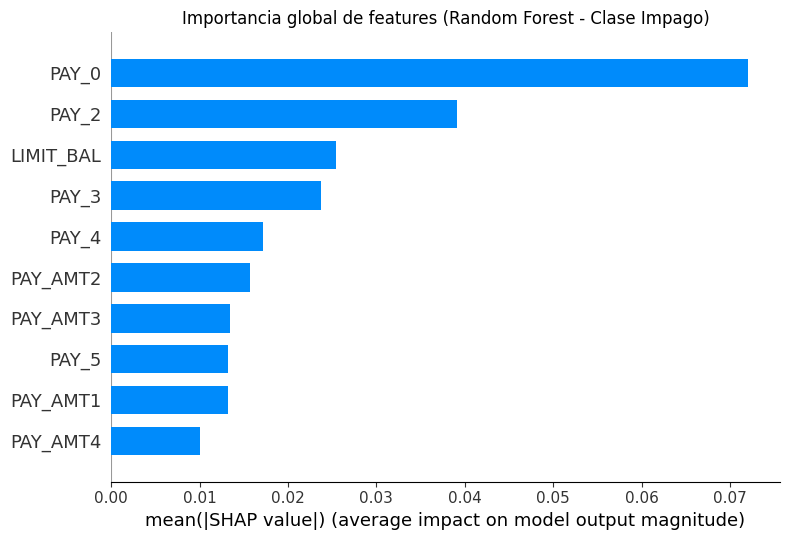

In [16]:
print("\n=== Importancia global (summary bar) ===")
shap.summary_plot(
    shap_values_positive,
    X_test,
    plot_type="bar",
    max_display=10,
    show=False
)
plt.title("Importancia global de features (Random Forest - Clase Impago)")
plt.tight_layout()
plt.show()


=== Explicación individual para el cliente 0 ===


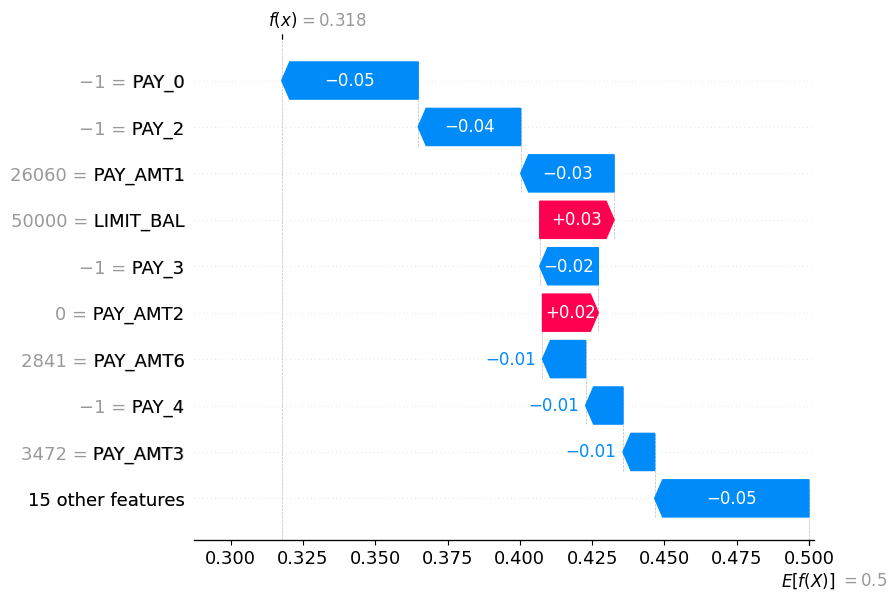

In [ ]:
# Coger un solo cliente (por ejemplo, el primero del conjunto de test)
cliente_idx = 0 

# Generar un objeto 'Explanation' que necesita el waterfall plot
explicacion_individual = shap.Explanation(
    values=shap_values_positive[cliente_idx], 
    base_values=base_value, 
    data=X_test.iloc[cliente_idx], 
    feature_names=X_test.columns
)

# Dibujar el waterfall plot
print(f"\n=== Explicación individual para el cliente {cliente_idx} ===")
shap.plots.waterfall(explicacion_individual)